In [1]:
import pandas as pd
import numpy as np
print("Kernel is working, pandas version:", pd.__version__)

Kernel is working, pandas version: 3.0.3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

np.random.seed(42)
sns.set_style('whitegrid')

# paths relative to project root (assumes notebook is run from notebooks/ folder,
# so we go one level up)
DATA_RAW = '../data/raw'
DATA_PROCESSED = '../data/processed'
OUTPUTS = '../outputs'

os.makedirs(DATA_RAW, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)

print("Setup complete")

Setup complete


In [3]:
import pandas as pd
import numpy as np
import os

np.random.seed(42)

# project root is one level up from notebooks/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_RAW = os.path.join(PROJECT_ROOT, 'data', 'raw')
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data', 'processed')

os.makedirs(DATA_RAW, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", DATA_RAW)
print("Processed data dir:", DATA_PROCESSED)

Project root: c:\Users\Admin\Desktop\restaurant_project
Raw data dir: c:\Users\Admin\Desktop\restaurant_project\data\raw
Processed data dir: c:\Users\Admin\Desktop\restaurant_project\data\processed


In [4]:
bom = pd.read_csv(os.path.join(DATA_RAW, 'dish_ingredient_bom.csv'))

print("BOM shape:", bom.shape)
print("Dishes:", bom.dish_id.nunique())
print("Ingredients:", bom.ingredient_id.nunique())
bom.head()

BOM shape: (90, 8)
Dishes: 18
Ingredients: 40


,dish_id,dish_name,dish_category,ingredient_id,ingredient_name,ingredient_category,quantity_per_plate,unit
0,D01,Idli,Breakfast,I01,Idli Rice,Grain,80,g
1,D01,Idli,Breakfast,I02,Urad Dal,Pulse,20,g
2,D01,Idli,Breakfast,I03,Fenugreek Seeds,Spice,1,g
3,D02,Plain Dosa,Breakfast,I01,Idli Rice,Grain,70,g
4,D02,Plain Dosa,Breakfast,I02,Urad Dal,Pulse,15,g


In [5]:
dishes = bom[['dish_id','dish_name','dish_category']].drop_duplicates().reset_index(drop=True)

outlets = pd.DataFrame({
    'outlet_id': ['O01','O02','O03'],
    'outlet_name': ['Koramangala - Office Hub', 'Jayanagar - Residential', 'Whitefield - Mixed'],
    'profile': ['office','residential','mixed']
})

start_date = '2023-01-01'
end_date = '2024-12-31'
dates = pd.date_range(start_date, end_date, freq='D')

# Festival dates (approx, South Indian relevant festivals) with dish boost map
festivals = {
    '2023-01-15': ('Pongal', {'D07':4.0,'D09':2.0,'D12':1.5}),
    '2023-04-14': ('Ugadi', {'D18':3.0,'D08':2.0}),
    '2023-08-29': ('Onam', {'D09':2.5,'D13':2.0,'D18':2.5}),
    '2023-11-12': ('Diwali', {'D18':3.0,'D08':2.5,'D14':1.8}),
    '2024-01-15': ('Pongal', {'D07':4.0,'D09':2.0,'D12':1.5}),
    '2024-04-09': ('Ugadi', {'D18':3.0,'D08':2.0}),
    '2024-09-15': ('Onam', {'D09':2.5,'D13':2.0,'D18':2.5}),
    '2024-11-01': ('Diwali', {'D18':3.0,'D08':2.5,'D14':1.8}),
}
festival_dates = {pd.Timestamp(k): v for k, v in festivals.items()}

base_demand = {'Breakfast': 90, 'Lunch': 70, 'Beverage': 120, 'Dessert': 40}
outlet_mult = {'office': 1.2, 'residential': 0.9, 'mixed': 1.0}

weekday_pattern = {
    'Breakfast': [1.0,1.0,1.0,1.0,1.0,1.15,1.2],
    'Lunch':     [1.1,1.1,1.1,1.1,1.15,0.85,0.8],
    'Beverage':  [0.9,0.9,0.9,0.9,1.0,1.2,1.3],
    'Dessert':   [0.7,0.7,0.7,0.7,0.9,1.4,1.5],
}

def profile_adjust(profile, category, wd):
    mult = 1.0
    if profile == 'office' and category == 'Lunch' and wd < 5:
        mult *= 1.25
    if profile == 'office' and wd >= 5:
        mult *= 0.7
    if profile == 'residential' and wd >= 5:
        mult *= 1.3
    return mult

rows = []
for _, outlet in outlets.iterrows():
    for _, dish in dishes.iterrows():
        cat = dish['dish_category']
        b = base_demand[cat]
        dish_pop = np.random.uniform(0.6, 1.4)
        for date in dates:
            wd = date.weekday()
            trend = 1 + 0.00015 * (date - pd.Timestamp(start_date)).days
            seasonal = weekday_pattern[cat][wd]
            prof_adj = profile_adjust(outlet['profile'], cat, wd)
            fest_mult = 1.0
            fest_name = None
            if date in festival_dates:
                fname, boosts = festival_dates[date]
                fest_mult = boosts.get(dish['dish_id'], 1.3)
                fest_name = fname
            expected = b * dish_pop * seasonal * prof_adj * fest_mult * trend * outlet_mult[outlet['profile']]
            noise = np.random.normal(1.0, 0.12)
            units_sold = max(0, int(round(expected * noise)))
            rows.append([date, outlet['outlet_id'], outlet['outlet_name'], dish['dish_id'], dish['dish_name'],
                         dish['dish_category'], wd, units_sold, fest_name])

sales = pd.DataFrame(rows, columns=['date','outlet_id','outlet_name','dish_id','dish_name',
                                     'dish_category','weekday','units_sold','festival'])
sales.to_csv(os.path.join(DATA_RAW, 'dish_sales_daily.csv'), index=False)

print(sales.shape)
sales.groupby('outlet_name')['units_sold'].sum()

(39474, 9)


outlet_name
Jayanagar - Residential     1330008
Koramangala - Office Hub    1414071
Whitefield - Mixed          1185948
Name: units_sold, dtype: int64

In [6]:
merged = sales.merge(bom[['dish_id','ingredient_id','ingredient_name','ingredient_category',
                           'quantity_per_plate','unit']], on='dish_id', how='left')

merged['consumption'] = merged['units_sold'] * merged['quantity_per_plate']

ingredient_daily = merged.groupby(
    ['date','outlet_id','outlet_name','ingredient_id','ingredient_name','ingredient_category','unit'],
    as_index=False
)['consumption'].sum()

ingredient_daily = ingredient_daily.sort_values(['outlet_id','ingredient_id','date']).reset_index(drop=True)
ingredient_daily.to_csv(os.path.join(DATA_PROCESSED, 'ingredient_consumption_daily.csv'), index=False)

print(ingredient_daily.shape)

# sanity check
check = ingredient_daily[(ingredient_daily.ingredient_id=='I01') & (ingredient_daily.outlet_id=='O01') & (ingredient_daily.date=='2023-01-02')]
print("Sanity check - Idli Rice consumption on 2023-01-02, Outlet O01:")
check

(87720, 8)
Sanity check - Idli Rice consumption on 2023-01-02, Outlet O01:


,date,outlet_id,outlet_name,ingredient_id,ingredient_name,ingredient_category,unit,consumption
1,2023-01-02,O01,Koramangala - Office Hub,I01,Idli Rice,Grain,g,36990


In [7]:
np.random.seed(7)

ingredients = bom[['ingredient_id','ingredient_name','ingredient_category','unit']].drop_duplicates().reset_index(drop=True)

# category -> (lead_time_days, safety_days, order_cover_days)
category_policy = {
    'Vegetable':  dict(lead_time=1, safety_days=1, order_cover_days=2),
    'Dairy':      dict(lead_time=1, safety_days=1, order_cover_days=2),
    'Herb':       dict(lead_time=1, safety_days=1, order_cover_days=2),
    'Meat':       dict(lead_time=1, safety_days=1, order_cover_days=2),
    'Grain':      dict(lead_time=3, safety_days=1, order_cover_days=4),
    'Pulse':      dict(lead_time=3, safety_days=1, order_cover_days=4),
    'Spice':      dict(lead_time=5, safety_days=2, order_cover_days=6),
    'Sweetener':  dict(lead_time=3, safety_days=1, order_cover_days=4),
    'Nuts':       dict(lead_time=3, safety_days=2, order_cover_days=5),
    'Oil':        dict(lead_time=3, safety_days=1, order_cover_days=4),
    'Fat':        dict(lead_time=3, safety_days=1, order_cover_days=4),
    'Beverage':   dict(lead_time=3, safety_days=1, order_cover_days=4),
}

def jittered_lead_time(base_lead_time):
    if np.random.random() < 0.12:
        return base_lead_time + np.random.randint(1, 3)
    return base_lead_time

results = []

for outlet_id in ingredient_daily.outlet_id.unique():
    outlet_cons = ingredient_daily[ingredient_daily.outlet_id == outlet_id]
    outlet_name = outlet_cons.outlet_name.iloc[0]

    for _, ing in ingredients.iterrows():
        ing_id = ing['ingredient_id']
        policy = category_policy[ing['ingredient_category']]
        lead_time = policy['lead_time']
        safety_days = policy['safety_days']
        order_cover_days = policy['order_cover_days']

        series = outlet_cons[outlet_cons.ingredient_id == ing_id].sort_values('date').reset_index(drop=True)
        if series.empty:
            continue

        rolling_avg = series['consumption'].shift(1).rolling(window=14, min_periods=1).mean()
        overall_avg = series['consumption'].mean()
        rolling_avg = rolling_avg.fillna(overall_avg)

        stock = overall_avg * (lead_time + safety_days + order_cover_days)
        pending_orders = {}

        dates_list = series['date'].tolist()
        consumptions = series['consumption'].tolist()
        rolling_avgs = rolling_avg.tolist()

        for i, date in enumerate(dates_list):
            if date in pending_orders:
                stock += pending_orders.pop(date)

            avg_daily_consumption = max(rolling_avgs[i], 1e-6)
            reorder_point = avg_daily_consumption * (lead_time + safety_days)
            order_qty = avg_daily_consumption * order_cover_days

            demand = consumptions[i]
            fulfilled = min(stock, demand)
            unmet_demand = demand - fulfilled
            stock = max(0, stock - demand)
            stockout_flag = 1 if unmet_demand > 0 else 0

            order_placed = 0
            if stock < reorder_point and not pending_orders:
                actual_lead_time = jittered_lead_time(lead_time)
                arrival_date = date + pd.Timedelta(days=actual_lead_time)
                pending_orders[arrival_date] = pending_orders.get(arrival_date, 0) + order_qty
                order_placed = 1

            results.append([
                date, outlet_id, outlet_name, ing_id, ing['ingredient_name'], ing['ingredient_category'], ing['unit'],
                round(demand, 1), round(stock, 1), stockout_flag, round(unmet_demand, 1),
                order_placed, round(reorder_point, 1)
            ])

inventory = pd.DataFrame(results, columns=[
    'date','outlet_id','outlet_name','ingredient_id','ingredient_name','ingredient_category','unit',
    'consumption','closing_stock','stockout_flag','unmet_demand','order_placed','reorder_point'
])

inventory.to_csv(os.path.join(DATA_PROCESSED, 'inventory_daily.csv'), index=False)

print(inventory.shape)
print("\nOverall stockout rate: {:.2f}%".format(inventory.stockout_flag.mean()*100))
inventory.groupby('ingredient_category')['stockout_flag'].mean().sort_values(ascending=False)*100

(87720, 13)

Overall stockout rate: 2.00%


ingredient_category
Vegetable    3.733470
Dairy        3.670771
Meat         3.602371
Herb         3.351573
Sweetener    2.599179
Grain        2.480620
Beverage     2.006384
Fat          1.915185
Pulse        1.808786
Oil          1.322389
Nuts         0.455996
Spice        0.311598
Name: stockout_flag, dtype: float64

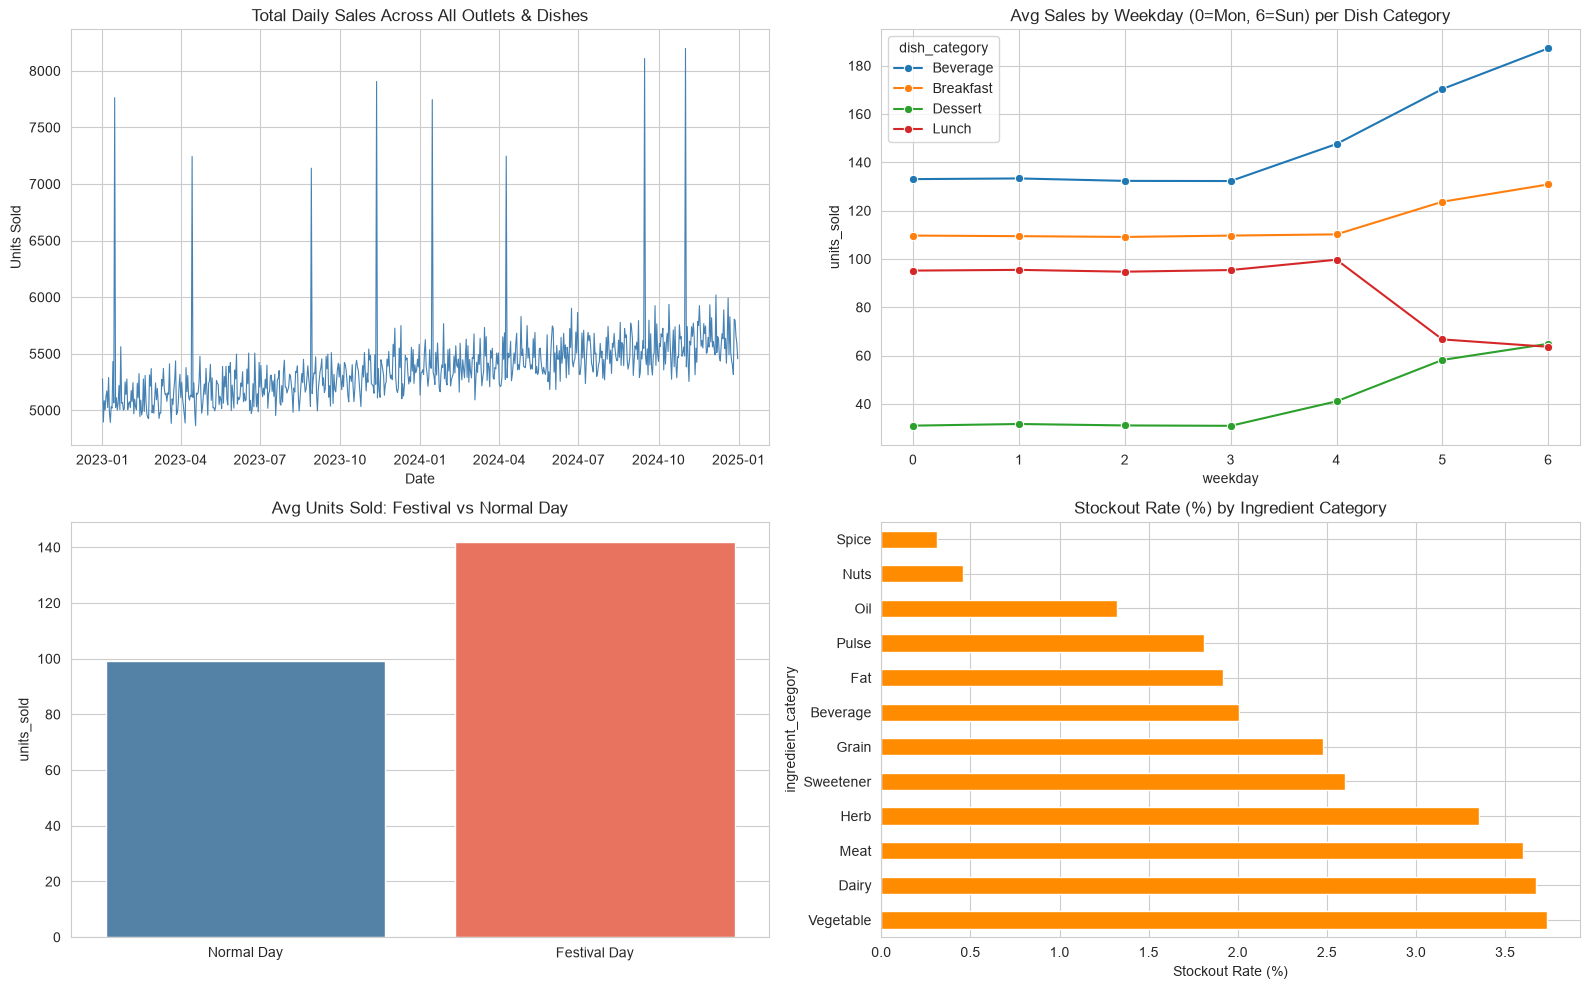

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Overall daily sales trend
daily_total = sales.groupby('date')['units_sold'].sum().reset_index()
axes[0,0].plot(daily_total['date'], daily_total['units_sold'], linewidth=0.8, color='steelblue')
axes[0,0].set_title('Total Daily Sales Across All Outlets & Dishes')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Units Sold')

# 2. Weekday pattern by dish category
weekday_cat = sales.groupby(['weekday','dish_category'])['units_sold'].mean().reset_index()
sns.lineplot(data=weekday_cat, x='weekday', y='units_sold', hue='dish_category', marker='o', ax=axes[0,1])
axes[0,1].set_title('Avg Sales by Weekday (0=Mon, 6=Sun) per Dish Category')

# 3. Festival vs normal day
sales['is_festival'] = sales['festival'].notna()
fest_compare = sales.groupby('is_festival')['units_sold'].mean().reset_index()
fest_compare['label'] = fest_compare['is_festival'].map({True: 'Festival Day', False: 'Normal Day'})
sns.barplot(data=fest_compare, x='label', y='units_sold', hue='label', ax=axes[1,0], palette=['steelblue','tomato'], legend=False)
axes[1,0].set_title('Avg Units Sold: Festival vs Normal Day')
axes[1,0].set_xlabel('')

# 4. Stockout rate by ingredient category
stockout_cat = inventory.groupby('ingredient_category')['stockout_flag'].mean().sort_values(ascending=False) * 100
stockout_cat.plot(kind='barh', ax=axes[1,1], color='darkorange')
axes[1,1].set_title('Stockout Rate (%) by Ingredient Category')
axes[1,1].set_xlabel('Stockout Rate (%)')

plt.tight_layout()
plt.show()

In [9]:
# festival lookup (date -> festival name), deduplicated
festival_lookup = sales[['date','festival']].drop_duplicates()

df = inventory.merge(festival_lookup, on='date', how='left')

# ---- Calendar features ----
df['weekday'] = df['date'].dt.weekday
df['is_weekend'] = (df['weekday'] >= 5).astype(int)
df['month'] = df['date'].dt.month
df['day_of_month'] = df['date'].dt.day
df['is_festival'] = df['festival'].notna().astype(int)

# days until next festival
festival_dates = sorted(festival_lookup[festival_lookup.festival.notna()]['date'].unique())
def days_to_next_festival(d):
    future = [fd for fd in festival_dates if fd >= d]
    return 999 if not future else (future[0] - d).days
df['days_to_next_festival'] = df['date'].apply(days_to_next_festival)

# ---- Lag & rolling features (per outlet + ingredient, sorted by date) ----
df = df.sort_values(['outlet_id','ingredient_id','date']).reset_index(drop=True)
group_cols = ['outlet_id','ingredient_id']

for lag in [1, 7, 14]:
    df[f'consumption_lag_{lag}'] = df.groupby(group_cols)['consumption'].shift(lag)

df['consumption_roll_mean_7'] = df.groupby(group_cols)['consumption'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
df['consumption_roll_std_7'] = df.groupby(group_cols)['consumption'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).std())
df['consumption_roll_mean_14'] = df.groupby(group_cols)['consumption'].transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())

df['closing_stock_lag_1'] = df.groupby(group_cols)['closing_stock'].shift(1)
df['stock_to_demand_ratio'] = df['closing_stock_lag_1'] / (df['consumption_roll_mean_7'] + 1e-6)
df['recent_stockout_flag'] = df.groupby(group_cols)['stockout_flag'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).max())

# ---- Categorical encodings ----
df['outlet_id'] = df['outlet_id'].astype('category')
df['ingredient_id'] = df['ingredient_id'].astype('category')
df['ingredient_category'] = df['ingredient_category'].astype('category')

# drop rows with insufficient lag history (first 14 days per outlet-ingredient group)
before = len(df)
df = df.dropna(subset=['consumption_lag_14', 'consumption_roll_mean_14']).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with insufficient history")

df.to_csv(os.path.join(DATA_PROCESSED, 'model_ready_features.csv'), index=False)

print("Final feature table shape:", df.shape)
print("\nTarget balance - stockout_flag:")
print(df['stockout_flag'].value_counts(normalize=True))

Dropped 1680 rows with insufficient history
Final feature table shape: (86040, 29)

Target balance - stockout_flag:
stockout_flag
0    0.97987
1    0.02013
Name: proportion, dtype: float64


In [19]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# restore categorical dtypes (may be lost on CSV round-trip if reloading fresh)
for col in ['outlet_id','ingredient_id','ingredient_category']:
    df[col] = df[col].astype('category')

# ---- Time-based train/test split (last 2 months = test) ----
split_date = df['date'].max() - pd.Timedelta(days=60)
train = df[df['date'] <= split_date].copy()
test = df[df['date'] > split_date].copy()

print(f"Train: {train.shape[0]} rows, {train.date.min().date()} to {train.date.max().date()}")
print(f"Test:  {test.shape[0]} rows, {test.date.min().date()} to {test.date.max().date()}")

# ---- Feature set for demand forecasting ----
# exclude columns computed FROM today's actual demand (leakage): closing_stock,
# stockout_flag, unmet_demand, order_placed, reorder_point
feature_cols = [
    'outlet_id', 'ingredient_id', 'ingredient_category',
    'weekday', 'is_weekend', 'month', 'day_of_month', 'is_festival', 'days_to_next_festival',
    'consumption_lag_1', 'consumption_lag_7', 'consumption_lag_14',
    'consumption_roll_mean_7', 'consumption_roll_std_7', 'consumption_roll_mean_14',
    'recent_stockout_flag'
]
target_col = 'consumption'

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

model = lgb.LGBMRegressor(
    n_estimators=2000, learning_rate=0.01, num_leaves=31,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(30, verbose=False)]
)

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mape = np.mean(np.abs((y_test - preds) / (y_test + 1e-6))) * 100

print("\n--- Demand Forecast Model Performance (test set) ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print("\n--- Feature Importance ---")
print(importance.to_string(index=False))

# save model + predictions
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(model, os.path.join(MODELS_DIR, 'demand_forecast_lgbm.pkl'))

test_results = test[['date','outlet_id','outlet_name','ingredient_id','ingredient_name','consumption']].copy()
test_results['predicted_consumption'] = preds
test_results.to_csv(os.path.join(DATA_PROCESSED, 'demand_forecast_test_predictions.csv'), index=False)
print("\nModel and predictions saved.")

Train: 78840 rows, 2023-01-15 to 2024-11-01
Test:  7200 rows, 2024-11-02 to 2024-12-31

--- Demand Forecast Model Performance (test set) ---
MAE:  592.10
RMSE: 1276.03
R2:   0.9921
MAPE: 13.17%

--- Feature Importance ---
                 feature  importance
       consumption_lag_7        3550
      consumption_lag_14        3414
   days_to_next_festival        2454
       consumption_lag_1        1801
                 weekday        1562
             is_festival        1518
consumption_roll_mean_14        1379
  consumption_roll_std_7        1316
            day_of_month        1196
               outlet_id        1102
           ingredient_id        1047
 consumption_roll_mean_7         916
                   month         813
              is_weekend         103
     ingredient_category          78
    recent_stockout_flag          71

Model and predictions saved.


In [22]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              precision_recall_curve, auc, confusion_matrix, classification_report)

# ---- Time-based split (same cutoff as demand model) ----
print(f"Train: {train.shape[0]} rows | stockout rate: {train['stockout_flag'].mean()*100:.2f}%")
print(f"Test:  {test.shape[0]} rows | stockout rate: {test['stockout_flag'].mean()*100:.2f}%")

# stock-position features are fair game here (known before today's demand plays out)
feature_cols_stockout = [
    'outlet_id', 'ingredient_id', 'ingredient_category',
    'weekday', 'is_weekend', 'month', 'day_of_month', 'is_festival', 'days_to_next_festival',
    'consumption_lag_1', 'consumption_lag_7', 'consumption_lag_14',
    'consumption_roll_mean_7', 'consumption_roll_std_7', 'consumption_roll_mean_14',
    'closing_stock_lag_1', 'stock_to_demand_ratio', 'recent_stockout_flag'
]
target_col = 'stockout_flag'

X_train_s, y_train_s = train[feature_cols_stockout], train[target_col]
X_test_s, y_test_s = test[feature_cols_stockout], test[target_col]

stockout_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=42, verbosity=-1
)

stockout_model.fit(
    X_train_s, y_train_s,
    eval_set=[(X_test_s, y_test_s)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(30, verbose=False)]
)

pred_proba = stockout_model.predict_proba(X_test_s)[:, 1]
pred_labels = stockout_model.predict(X_test_s)

precision = precision_score(y_test_s, pred_labels)
recall = recall_score(y_test_s, pred_labels)
f1 = f1_score(y_test_s, pred_labels)
prec_curve, rec_curve, _ = precision_recall_curve(y_test_s, pred_proba)
pr_auc = auc(rec_curve, prec_curve)

print(f"\nPrecision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f} | PR-AUC: {pr_auc:.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_s, pred_labels))
print("\n", classification_report(y_test_s, pred_labels, target_names=['No Stockout','Stockout']))

importance_s = pd.DataFrame({
    'feature': feature_cols_stockout,
    'importance': stockout_model.feature_importances_
}).sort_values('importance', ascending=False)
print(importance_s.to_string(index=False))

joblib.dump(stockout_model, os.path.join(MODELS_DIR, 'stockout_classifier_lgbm.pkl'))

test_results_s = test[['date','outlet_id','outlet_name','ingredient_id','ingredient_name','stockout_flag']].copy()
test_results_s['stockout_probability'] = pred_proba
test_results_s['predicted_stockout'] = pred_labels
test_results_s.to_csv(os.path.join(DATA_PROCESSED, 'stockout_test_predictions.csv'), index=False)
print("\nModel and predictions saved.")

Train: 78840 rows | stockout rate: 2.02%
Test:  7200 rows | stockout rate: 1.89%

Precision: 0.176 | Recall: 0.971 | F1: 0.298 | PR-AUC: 0.284

Confusion Matrix:
 [[6447  617]
 [   4  132]]

               precision    recall  f1-score   support

 No Stockout       1.00      0.91      0.95      7064
    Stockout       0.18      0.97      0.30       136

    accuracy                           0.91      7200
   macro avg       0.59      0.94      0.63      7200
weighted avg       0.98      0.91      0.94      7200

                 feature  importance
   stock_to_demand_ratio         352
     closing_stock_lag_1         280
           ingredient_id         270
      consumption_lag_14         139
                 weekday         135
       consumption_lag_7         114
   days_to_next_festival         114
  consumption_roll_std_7         107
               outlet_id          85
       consumption_lag_1          84
             is_festival          69
                   month          59
